# Hyperparamteroptimierung
Bibliotheken importieren und Datensatz laden.

In [3]:
# --- Moons Beispiel ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

x, y = make_moons(n_samples=500, noise=0.3, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

Experimentieren Sie hier mit dem Parameter k und versuchen Sie, die beste Testgenauigkeit zu erzielen.

Moons training accuracy: 0.767164
Moons testing accuracy: 0.812121


C:\Users\mathi\AppData\Local\Temp\ipykernel_8264\506637351.py:19: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k', s=50, marker='x', label='Testdaten')


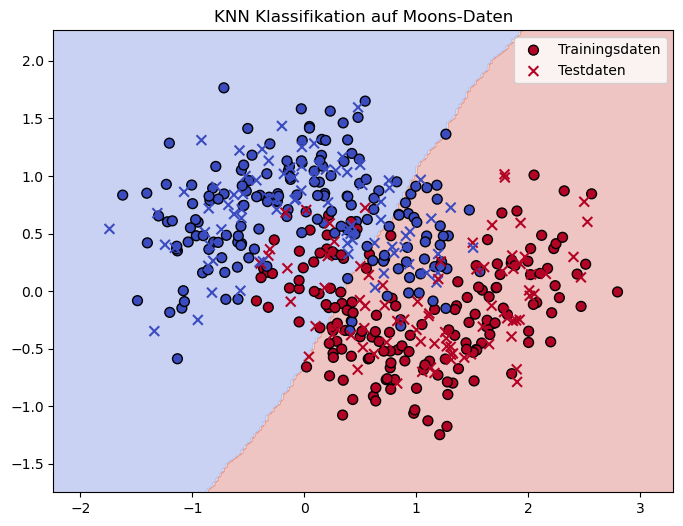

In [15]:
k = 250
knn_moons = KNeighborsClassifier(n_neighbors=k)
knn_moons.fit(x_train, y_train)

train_acc = knn_moons.score(x_train, y_train)
test_acc = knn_moons.score(x_test, y_test)

print("Moons training accuracy: %f" % train_acc)
print("Moons testing accuracy: %f" % test_acc)

# Plot Moons Entscheidung
plt.figure(figsize=(8,6))
xx, yy = np.meshgrid(np.linspace(x[:,0].min()-0.5, x[:,0].max()+0.5, 200),
np.linspace(x[:,1].min()-0.5, x[:,1].max()+0.5, 200))
Z = knn_moons.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k', s=50, label='Trainingsdaten')
plt.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap=plt.cm.coolwarm, edgecolor='k', s=50, marker='x', label='Testdaten')
plt.title('KNN Klassifikation auf Moons-Daten')
plt.legend()
plt.show()